# Reduce spam from original emails csv using trained cls model

In [ ]:
import pandas as pd
import joblib

# use classifier trained on PII-masked emails so that 
clf = joblib.load("clf_pii.joblib")

df = pd.read_csv("emails_preprocessed.csv")

/tmp/ipykernel_1651692/232232482.py:6: DtypeWarning: Columns (14: X-bcc, 18: Time, 19: Attendees) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("emails_preprocessed.csv")


In [13]:
df["spam_label"] = clf.predict(df["embed_text"])

In [14]:
df["spam_label"].value_counts()

spam_label
ham     180706
spam     46211
Name: count, dtype: int64

In [15]:
# analyze identified spam emails
df[df["spam_label"] == "spam"].head()

,file,Message-ID,Date,From,To,Cc,Bcc,Subject,Mime-Version,Content-Type,...,signature,attachment_count,attachment_names,parse_error,embed_text,ctfidf_text,full_message,subj_norm,thread_id,spam_label
0,allen-p/all_documents/157.,<12929996.1075855668941.JavaMail.evans@thyme>,"Mon, 31 Dec 1979 16:00:00 -0800",phillip.allen@enron.com,muller@thedoghousemail.com,NaN,NaN,Re: (No Subject),1.0,"text/plain; charset=""us-ascii""",...,NaN,0,[],NaN,Re: (No Subject) How is your racing going? Wha...,re no subject how is your racing going what ca...,Re: (No Subject) How is your racing going? Wha...,(no subject),0,spam
11,arnold-j/all_documents/547.,<10652037.1075857579318.JavaMail.evans@thyme>,"Mon, 31 Dec 1979 16:00:00 -0800",john.arnold@enron.com,john.thomas@enron.com,NaN,NaN,Re: dude,1.0,"text/plain; charset=""us-ascii""",...,NaN,0,[],NaN,Re: dude What's up dude...\nSorry I've been so...,re dude whats up dude sorry ive been so delinq...,Re: dude What's up dude...\nSorry I've been so...,dude,11,spam
13,bass-e/all_documents/10.,<9677270.1075848342471.JavaMail.evans@thyme>,"Mon, 31 Dec 1979 16:00:00 -0800",eric.bass@enron.com,NaN,NaN,NaN,NaN,1.0,"text/plain; charset=""us-ascii""",...,NaN,0,[],NaN,8/2-8/8\n$239/night\nritz carlton st thomas\nc...,8288 239night ritz carlton st thomas confirm 8...,8/2-8/8\n$239/night\nritz carlton st thomas\nc...,NaN,13,spam
15,bass-e/all_documents/9.,<26711157.1075848342449.JavaMail.evans@thyme>,"Mon, 31 Dec 1979 16:00:00 -0800",eric.bass@enron.com,bob.dunn@enron.com,NaN,NaN,Title Co,1.0,"text/plain; charset=""us-ascii""",...,NaN,0,[],NaN,Title Co American Title\n5120 Woodway #7029 77...,title co american title 5120 woodway 7029 7705...,Title Co American Title\n5120 Woodway #7029 77...,title co,15,spam
16,baughman-d/all_documents/160.,<10730757.1075848314468.JavaMail.evans@thyme>,"Mon, 31 Dec 1979 16:00:00 -0800",don.baughman@enron.com,NaN,NaN,NaN,Don't forget to register!,1.0,"text/plain; charset=""us-ascii""",...,NaN,0,[],NaN,Don't forget to register! To register your Pal...,dont forget to register to register your palm ...,Don't forget to register! To register your Pal...,don't forget to register!,16,spam


[nltk_data] Downloading package stopwords to /home/marco/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


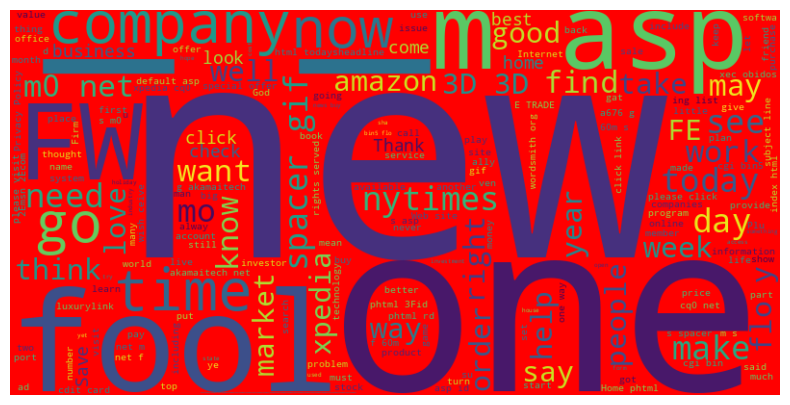

In [29]:
# wordcloud of spam emails

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import re

words = " ".join(df[df["spam_label"] == "spam"]["embed_text"])
words = " ".join([w.strip() for w in words.split() if w.strip()])

nltk.download("stopwords")
stopwords = set(stopwords.words("english"))

# remove stopwords
words = " ".join([w for w in words.split() if w not in stopwords])

# remove Presidio PII placeholders (default format is <ENTITY_TYPE>, not [ENTITY_TYPE])
_PII = r"LOCATION|PERSON|EMAIL_ADDRESS|PHONE_NUMBER|US_SSN|CREDIT_CARD|IBAN_CODE"
words = re.sub(rf"<({_PII})>", "", words)

# remove strings that are too frequent
too_frequent = r"e|email|mail|RE|re|Re"
words = re.sub(rf"\b{too_frequent}\b", "", words)

# Create a word cloud of spam emails
wordcloud = WordCloud(width=800, height=400, background_color="red").generate(words)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

[nltk_data] Downloading package stopwords to /home/marco/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


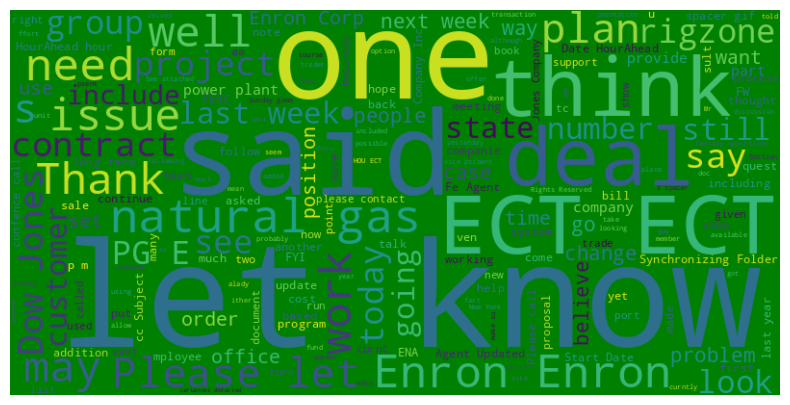

In [30]:
# wordcloud of ham emails

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import re

words = " ".join(df[df["spam_label"] == "ham"]["embed_text"])
words = " ".join([w.strip() for w in words.split() if w.strip()])

nltk.download("stopwords")
stopwords = set(stopwords.words("english"))

# remove stopwords
words = " ".join([w for w in words.split() if w not in stopwords])

# remove Presidio PII placeholders (default format is <ENTITY_TYPE>, not [ENTITY_TYPE])
_PII = r"LOCATION|PERSON|EMAIL_ADDRESS|PHONE_NUMBER|US_SSN|CREDIT_CARD|IBAN_CODE"
words = re.sub(rf"<({_PII})>", "", words)

# remove strings that are too frequent
too_frequent = r"e|email|mail|RE|re|Re"
words = re.sub(rf"\b{too_frequent}\b", "", words)

# Create a word cloud of spam emails
wordcloud = WordCloud(width=800, height=400, background_color="green").generate(words)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## Execute spam model onto emails_preprocessed.csv with replacement of data

In [31]:
# replace current csv with new csv without spam emails
df = df[df["spam_label"] == "ham"]
df.to_csv("emails_preprocessed_no_spam.csv", index=False)


In [32]:
df.info()

<class 'pandas.DataFrame'>
Index: 180706 entries, 1 to 226916
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   file                       180706 non-null  str    
 1   Message-ID                 180706 non-null  str    
 2   Date                       180706 non-null  str    
 3   From                       180706 non-null  str    
 4   To                         174747 non-null  str    
 5   Cc                         52578 non-null   str    
 6   Bcc                        52578 non-null   str    
 7   Subject                    175282 non-null  str    
 8   Mime-Version               180682 non-null  float64
 9   Content-Type               180682 non-null  str    
 10  Content-Transfer-Encoding  180682 non-null  str    
 11  X-From                     180682 non-null  str    
 12  X-To                       177280 non-null  str    
 13  X-cc                       53054 non-null   s